In [11]:
import numpy as np 
import nltk
import re
import seaborn as sns 
import matplotlib.pyplot as plt 

from nltk.corpus import stopwords
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 

In [2]:
reviews = load_files('txt_sentoken')  ## leemos los archivos 
my_docs , y = reviews.data, reviews.target  ## coloca en my_doc los valores ,y son etiquetas si es 0 o 1
print(reviews.target_names)

['neg', 'pos']


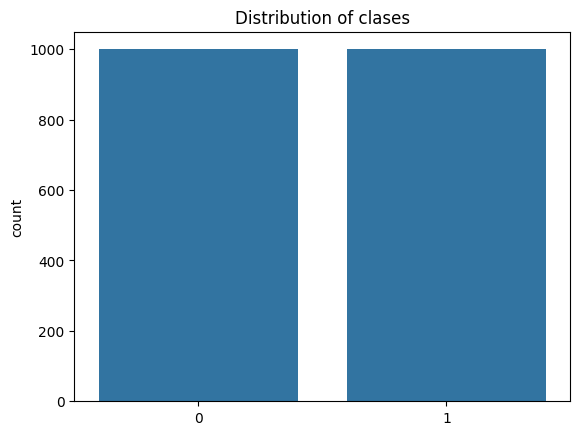

In [3]:
sns.countplot(x=y).set_title('Distribution of clases')
plt.show()

In [4]:
## Preprocesamiento 
corpus =[]  ## lita vacia para guardar los archivos limpios 
for i in range(0,len(my_docs)):  ## leemos cada review 
    reviews = re.sub(r'\W', ' ',str(my_docs[i]))   #eliminamos signos de puntuacion y los transforma en espacios 
    reviews = reviews.lower()    ##Pasamos todo a minusculas 
    reviews = re.sub(r'^br$',' ', reviews)       #^inicio, $ final de parafo, reemplazamos por espacio 
    reviews = re.sub(r'\s+br\s',' ',reviews)
    # eliminamos palabras de una sola letra 
    reviews = re.sub(r'\s+[a-z]\s+',' ',reviews)
    reviews = re.sub(r'^b\s+','',reviews) 
    # Removemos espacios entre oraciones 
    reviews = re.sub(r'\s+',' ',reviews)
    corpus.append(reviews)


In [14]:
TFIDF = TfidfVectorizer(max_features=1000,min_df=2,max_df=0.6,
                        stop_words = stopwords.words('english'))   # elegimos las 1000 palabras mas frecuentes 
TFIDF.fit(corpus)
X = TFIDF.transform(corpus)      ## de texto a matriz
corpus.append(reviews) 
X.shape

(2005, 1000)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1234)

In [ ]:
LR = LogisticRegression()
LR.fit(X_train,y_train)

In [ ]:
y_pred = LR.predict(X_test)
conf_ma = confusion_matrix(y_test,y_pred)
acc = accuracy_score(y_test,y_pred)

In [ ]:
print(conf_ma)
print(f'Accuracy:{acc:.3f}')

In [ ]:
def limpiar(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'^br$',' ', text)       #^inicio, $ final de parafo, reemplazamos por espacio 
    text = re.sub(r'\s+br\s',' ',text)
    # eliminamos palabras de una sola letra 
    text = re.sub(r'\s+[a-z]\s+',' ',text)
    text = re.sub(r'^b\s+','',text) 
    # Removemos espacios entre oraciones 
    text = re.sub(r'\s+',' ',text)
    return text.strip()


In [ ]:
def predic_review(text):
    tex_clean = limpiar(text)
    vec = TFIDF.transform([text_clean])
    pred = LR.predict(vec)[0]
    
    return reviews.target_names[pred]

In [ ]:
predic_review('This movie was absolute fantastic!')

In [ ]:
for w in ['fantastic','absolutely','movie','this']:
    print(w,w in TFIDF.vocabulary_)

In [8]:
## modifica mos el estimador DFITF
TFIDF = TfidfVectorizer(max_features=10000,min_df=2,max_df=0.8,
                        stop_words = stopwords.words('english'))   # elegimos las 1000 palabras mas frecuentes 
TFIDF.fit(corpus)
X = TFIDF.transform(corpus)      ## de texto a matriz
corpus.append(reviews) 
X.shape

(2002, 10000)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1234)
LR = LogisticRegression()
LR.fit(X_train,y_train)

In [10]:
for w in ['fantastic','absolutely','movie','this']:
    print(w,w in TFIDF.vocabulary_)

fantastic True
absolutely True
movie True
this False


## Ejercicio 2 

In [18]:
import numpy as np 
import nltk 

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.decomposition import TruncatedSVD

In [19]:
my_docs = ["The economic slowdown is becoming more severe",
           "The movie was simply awesome",
           "I like cooking my own food",
           "Samsung is announcing a new technology",
           "Machine Learning is an example of awesome technology",
           "All of us were excited at the movie",
           "We have to do more to reverse the economic slowdown"]

In [23]:
my_docs = [x.lower() for x in my_docs]
my_stop_words = ['us','like']

In [25]:
## Declaramos el estimador 
vectorizer = TfidfVectorizer(max_features=15,min_df=1,max_df=3,
                            stop_words=stopwords.words('english')+my_stop_words)

X = vectorizer.fit_transform(my_docs)
X.shape

(7, 15)

In [ ]:
feature = vectorizer.get_feature_names_out()
print(feature)

['awesome' 'becoming' 'cooking' 'economic' 'example' 'excited' 'food'
 'learning' 'machine' 'movie' 'new' 'reverse' 'samsung' 'slowdown'
 'technology']


In [ ]:
n_topic = 4 
svd = TruncatedSVD(n_components=n_topic, n_iter=100,)
svd.fit(X) ## Regresa una matriz de 4x15 

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",4
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",100
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [ ]:
vt = svd.components_
print(vt)
vt.shape
vtabs = np.abs(vt)


[[-7.34050731e-16  3.64848333e-01  2.00593281e-17  6.05710899e-01
  -1.47136689e-16  1.80451501e-16  2.00593281e-17 -1.47136689e-16
  -1.47136689e-16 -3.65682239e-16  2.67734801e-17  3.64848333e-01
   2.67734801e-17  6.05710899e-01 -9.98846647e-17]
 [ 5.24870792e-01 -2.13519807e-16 -2.68505508e-16  1.30320764e-16
   1.58868996e-01  3.55524692e-01 -2.68505508e-16  1.58868996e-01
   1.58868996e-01  6.88111908e-01  7.49353714e-02  4.78197891e-16
   7.49353714e-02  1.30320764e-16  1.94077704e-01]
 [ 1.10873880e-01 -1.17017495e-16  8.79082832e-16  7.04851746e-17
   2.53945040e-01 -2.94139077e-01  9.08567711e-16  2.53945040e-01
   2.53945040e-01 -3.44083006e-01  3.89758799e-01  1.05713533e-16
   3.89758799e-01  7.04851726e-17  5.34329467e-01]
 [-7.03426213e-17  2.89138397e-17  7.07106781e-01 -3.12939615e-17
  -6.17937984e-16  3.78823608e-16  7.07106781e-01 -6.17937984e-16
  -6.17937984e-16  8.06027027e-16  2.35500550e-16 -4.88394923e-17
   2.35500550e-16 -3.53838585e-18 -3.08158159e-16]]


In [32]:
n_top = 3 
for i in range(n_topic):
    topic_feature = [feature[idx] for idx in np.argsort(-vtabs[i,:])]
    topic_feature_top = topic_feature[0:n_top]
    #matriz de la lista de cada topico
    if i == 0:
        topic_matrix = [topic_feature_top]
    else:
        topic_matrix.append(topic_feature_top)

In [ ]:
topic_matrix

[['economic', 'slowdown', 'reverse'],
 ['movie', 'awesome', 'excited'],
 ['technology', 'new', 'samsung'],
 ['cooking', 'food', 'movie']]

In [36]:
topic_name =  ['Econimic','Movie','Technology','Cuisine']
#etiquetado de los documentos 
n_doc = len(my_docs)
for i in range(n_doc):
    score_pick = 0
    topic_pick = 0
    token_doc = nltk.word_tokenize(my_docs[i])
    for j in range(n_topic): # comparar topico con cada tema 
        found = [x in topic_matrix[j] for x in token_doc]  # buscamo si le x esta en los temas
        score = np.sum(found)
        # comparacion de score en el documento 
        if score > score_pick :
            score_pick = score
            topic_pick = j 
    print('Documentos: '+str(i+1)+' Tema: '+ topic_name[topic_pick] )

Documentos: 1 Tema: Econimic
Documentos: 2 Tema: Movie
Documentos: 3 Tema: Cuisine
Documentos: 4 Tema: Technology
Documentos: 5 Tema: Movie
Documentos: 6 Tema: Movie
Documentos: 7 Tema: Econimic


## Ejemplo_3

In [37]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [39]:
vectorizer =  CountVectorizer(max_features=15, min_df=1,max_df=3, stop_words=list(ENGLISH_STOP_WORDS))
X = vectorizer.fit_transform(my_docs)

In [43]:
## Vocabulario 
feature = vectorizer.get_feature_names_out()
print(feature)

['announcing' 'awesome' 'economic' 'example' 'excited' 'food' 'learning'
 'like' 'machine' 'movie' 'new' 'reverse' 'samsung' 'slowdown'
 'technology']


In [44]:
n_topic = 4
lda =LatentDirichletAllocation(n_components=n_topic, random_state=123)
my_docs_topic = lda.fit_transform(X)

In [45]:
topic_comp = lda.components_
topic_comp.shape

(4, 15)

In [46]:
n_top = 3
for i in range(n_topic):
    topic_feature = [feature[idx] for idx in np.argsort(-topic_comp[i,:])]
    topic_feature_top = topic_feature[0:n_top]
    if i == 0:
        topic_matrix = [topic_feature_top]
    else : 
        topic_matrix.append(topic_feature_top) 

In [47]:
topic_matrix

[['economic', 'slowdown', 'learning'],
 ['movie', 'excited', 'awesome'],
 ['technology', 'announcing', 'new'],
 ['awesome', 'movie', 'technology']]

In [48]:
topic_name = ['Technology','Cuisine','Movie','Economy']

In [52]:
n_docs = len(my_docs)
for i in range(n_docs): 
    topic_pick = np.argmax(my_docs_topic[i,:])
    print('Document: '+ str(i+1)+ ' Tema '+ topic_name[topic_pick])

Document: 1 Tema Technology
Document: 2 Tema Economy
Document: 3 Tema Movie
Document: 4 Tema Movie
Document: 5 Tema Technology
Document: 6 Tema Cuisine
Document: 7 Tema Technology
